<a href="https://colab.research.google.com/github/Guna1213/ASD_Prediction_Using_Machine_Learning/blob/main/ASD_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost

In [ ]:
from google.colab import files
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('eye_dataset.csv', low_memory=False, dtype={'Participant': str})

print(df.shape)
print(df.columns.tolist())
print(df.head(3))

FileNotFoundError: [Errno 2] No such file or directory: 'eye_dataset.csv'

In [ ]:
cols = [
    'Participant',
    'Category Right',
    'Pupil Diameter Right [mm]',
    'Pupil Diameter Left [mm]',
    'Point of Regard Right X [px]',
    'Point of Regard Right Y [px]',
    'Point of Regard Left X [px]',
    'Point of Regard Left Y [px]',
    'Gaze Vector Right X',
    'Gaze Vector Right Y',
    'Gaze Vector Left X',
    'Gaze Vector Left Y'
]
df = df[cols]
df = df.replace('-', np.nan)
df = df.dropna()
print(df.shape)

(256811, 12)


In [ ]:
print(df['Participant'].unique())
# Only 'Unidentified(Neg)' = ASD | all numeric IDs = Normal

df['Label'] = df['Participant'].apply(
    lambda x: 1 if 'Neg' in str(x) else 0
)
print(df['Label'].value_counts())
# 0 (Normal): ~204,648  |  1 (ASD): ~80,283

['Unidentified(Neg)' '54' '59' '25' '26' '58' '29' '56' '30' '57' '52'
 '31' '49' '36' '14' '28' '13' '45' '43' '51' '44' '47' '48' '50' '19'
 '17' '18' '21' '20' '42' '46' '53' '55' '27' '23']
Label
0    184138
1     72673
Name: count, dtype: int64


In [ ]:
# FIX: dataset has 4 categories — map all of them
category_map = {
    'Fixation':  0,
    'Saccade':   1,
    'Blink':     2,
    'Separator': 3
}
df['Category Right'] = df['Category Right'].map(category_map)

X = df.drop(['Participant', 'Label'], axis=1)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
y = df['Label']

print(X.shape, y.shape)

(256811, 11) (256811,)


In [ ]:
from sklearn.model_selection import train_test_split

# FIX: stratify=y keeps class balance in train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (205448, 11)
Test:  (51363, 11)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# FIX: class_weight='balanced' handles imbalanced data (72/28 split)
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1   # use all CPU cores
)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# FIX: target_names shows 'Normal'/'ASD' instead of 0/1
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'ASD']))

Accuracy: 0.9527480871444425
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.97     36828
         ASD       0.88      0.96      0.92     14535

    accuracy                           0.95     51363
   macro avg       0.93      0.95      0.94     51363
weighted avg       0.96      0.95      0.95     51363



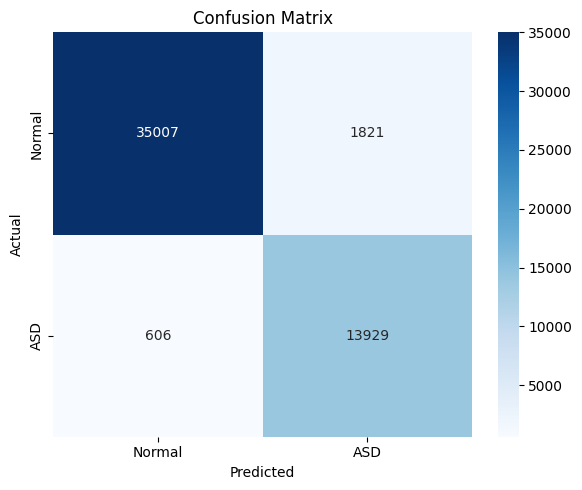

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal', 'ASD'],
            yticklabels=['Normal', 'ASD'],
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

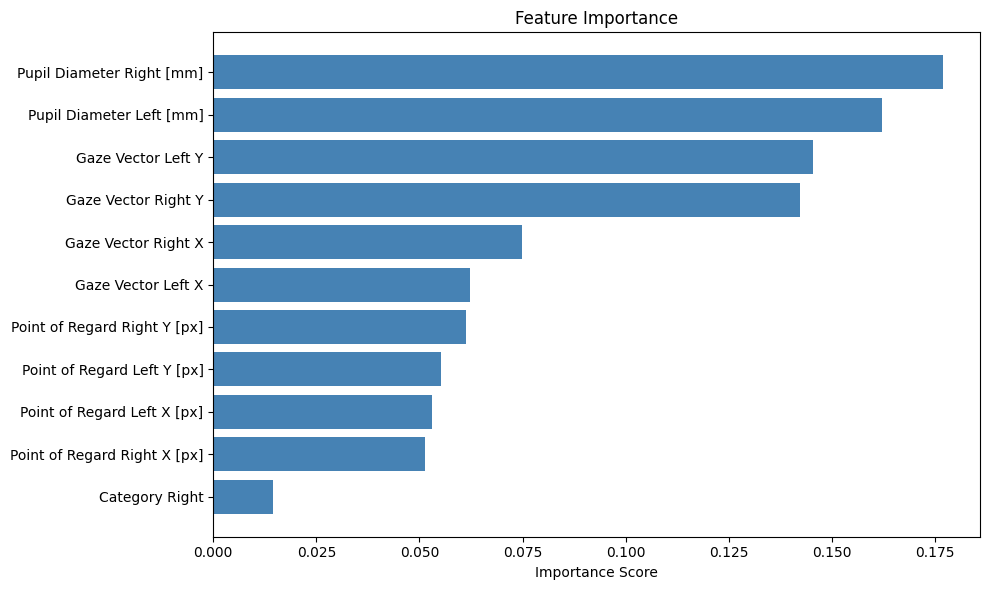

In [ ]:
importances = model.feature_importances_
features = X.columns

# FIX: sorted for readability
sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], importances[sorted_idx], color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Input widgets
cat    = widgets.Dropdown(options=[('Fixation',0),('Saccade',1),('Blink',2),('Separator',3)], description='Category R:')
pd_r   = widgets.FloatText(value=3.5, description='Pupil R (mm):')
pd_l   = widgets.FloatText(value=3.5, description='Pupil L (mm):')
por_rx = widgets.FloatText(value=640,  description='PoR Right X:')
por_ry = widgets.FloatText(value=512,  description='PoR Right Y:')
por_lx = widgets.FloatText(value=640,  description='PoR Left X:')
por_ly = widgets.FloatText(value=512,  description='PoR Left Y:')
gv_rx  = widgets.FloatText(value=0.0,  description='GV Right X:')
gv_ry  = widgets.FloatText(value=0.0,  description='GV Right Y:')
gv_lx  = widgets.FloatText(value=0.0,  description='GV Left X:')
gv_ly  = widgets.FloatText(value=0.0,  description='GV Left Y:')
btn    = widgets.Button(description='Predict ASD', button_style='primary')
out    = widgets.Output()

def on_click(b):
    with out:
        out.clear_output()
        sample = np.array([[cat.value, pd_r.value, pd_l.value,
                            por_rx.value, por_ry.value, por_lx.value, por_ly.value,
                            gv_rx.value, gv_ry.value, gv_lx.value, gv_ly.value]])
        pred = model.predict(sample)
        prob = model.predict_proba(sample)
        result = "ASD Detected" if pred[0] == 1 else "Normal (No ASD)"
        conf   = round(max(prob[0]) * 100, 2)
        print(f"Result     : {result}")
        print(f"Confidence : {conf}%")

btn.on_click(on_click)
display(cat, pd_r, pd_l, por_rx, por_ry, por_lx, por_ly, gv_rx, gv_ry, gv_lx, gv_ly, btn, out)

Dropdown(description='Category R:', options=(('Fixation', 0), ('Saccade', 1), ('Blink', 2), ('Separator', 3)),…

FloatText(value=3.5, description='Pupil R (mm):')

FloatText(value=3.5, description='Pupil L (mm):')

FloatText(value=640.0, description='PoR Right X:')

FloatText(value=512.0, description='PoR Right Y:')

...

FloatText(value=0.0, description='GV Right Y:')

FloatText(value=0.0, description='GV Left X:')

FloatText(value=0.0, description='GV Left Y:')

Button(button_style='primary', description='Predict ASD', style=ButtonStyle())

Output()

(Manual Input):
The first version of the ASD prediction tool asked the user to manually type in eye tracking measurements such as pupil diameter, point of regard, and gaze vector values. These numbers normally come from a specialised eye tracking device like Tobii or SMI. Most people do not have access to such equipment, so entering these values manually was difficult and not practical for everyday use.

(Eye Image Input):
The new version removes that difficulty completely. The user simply uploads a photo of their eye — taken from a phone or camera — and the system automatically analyses the image. It detects the pupil using computer vision, extracts all the necessary measurements from the image itself, and then predicts whether the eye patterns suggest ASD or Normal. No special equipment is needed. No manual numbers to enter. Just upload and get a result.

In [ ]:
!pip install opencv-python-headless numpy matplotlib

In [ ]:
from google.colab import files
import cv2, numpy as np
import matplotlib.pyplot as plt

uploaded   = files.upload()
image_path = list(uploaded.keys())[0]
print("Uploaded:", image_path)

Saving VIJAY.jpg to VIJAY.jpg
Uploaded: VIJAY.jpg


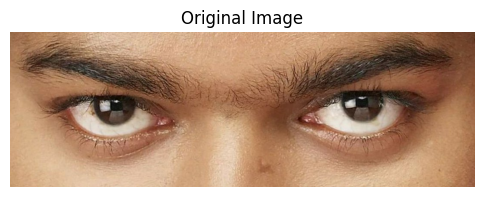

Image size: (360, 1080, 3)


In [ ]:
img     = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w    = img.shape[:2]

plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()
print("Image size:", img.shape)

Darkest point: (824, 155), value: 0.0
Pupil at (814, 148), radius: 61px


/tmp/ipykernel_6298/2549013089.py:41: RuntimeWarning: overflow encountered in scalar subtract
  dist   = np.sqrt((cx_abs - dark_x)**2 + (cy_abs - dark_y)**2)


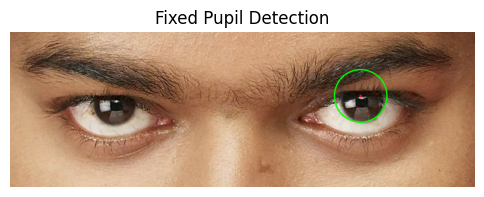

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# FIX 1: Mask out bright areas — pupil is always the darkest region
_, bright_mask = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY)
gray_masked    = gray.copy()
gray_masked[bright_mask == 255] = 255

# FIX 2: Find the darkest point — this is always the pupil
min_val, _, min_loc, _ = cv2.minMaxLoc(gray_masked)
dark_x, dark_y         = min_loc
print(f"Darkest point: ({dark_x}, {dark_y}), value: {min_val}")

# FIX 3: Search for circles only near that dark region
roi_size = min(w, h) // 2
rx1 = max(0, dark_x - roi_size)
ry1 = max(0, dark_y - roi_size)
rx2 = min(w, dark_x + roi_size)
ry2 = min(h, dark_y + roi_size)

gray_roi      = gray[ry1:ry2, rx1:rx2]
gray_roi_blur = cv2.GaussianBlur(gray_roi, (7, 7), 0)

circles = cv2.HoughCircles(
    gray_roi_blur,
    cv2.HOUGH_GRADIENT,
    dp=1, minDist=20,
    param1=30, param2=18,
    minRadius=8,
    maxRadius=min(roi_size, 70)
)

pupil_x, pupil_y, pupil_r = dark_x, dark_y, 20  # fallback

if circles is not None:
    circles = np.uint16(np.around(circles))
    # FIX 4: Pick the circle closest to the darkest point
    best_dist = float('inf')
    for c in circles[0]:
        cx_abs = c[0] + rx1
        cy_abs = c[1] + ry1
        dist   = np.sqrt((cx_abs - dark_x)**2 + (cy_abs - dark_y)**2)
        if dist < best_dist:
            best_dist          = dist
            pupil_x, pupil_y, pupil_r = cx_abs, cy_abs, c[2]
    print(f"Pupil at ({pupil_x}, {pupil_y}), radius: {pupil_r}px")
else:
    print("Hough failed — using darkest point as fallback")

# Draw result
img_result = img_rgb.copy()
cv2.circle(img_result, (pupil_x, pupil_y), pupil_r, (0,255,0), 2)
cv2.circle(img_result, (pupil_x, pupil_y), 3,       (255,0,0), -1)

plt.figure(figsize=(6,4))
plt.imshow(img_result)
plt.title('Fixed Pupil Detection')
plt.axis('off')
plt.show()

In [ ]:
pupil_mm = round(pupil_r * 2 * 0.05, 2)   # px to mm

por_x  = round((pupil_x / w) * 1280, 2)
por_y  = round((pupil_y / h) * 1024, 2)

cx, cy = w // 2, h // 2
gaze_x = round((pupil_x - cx) / cx, 4)
gaze_y = round((pupil_y - cy) / cy, 4)

mask = np.zeros(gray.shape, dtype=np.uint8)
cv2.circle(mask, (int(pupil_x), int(pupil_y)), int(pupil_r), 255, -1)
darkness = round(float(cv2.mean(gray, mask=mask)[0]), 2)

print("Pupil diameter (mm) :", pupil_mm)
print("Point of regard X/Y :", por_x, por_y)
print("Gaze vector X/Y     :", gaze_x, gaze_y)
print("Pupil darkness      :", darkness)

Pupil diameter (mm) : 6.1
Point of regard X/Y : 964.74 420.98
Gaze vector X/Y     : 0.5074 363.9111
Pupil darkness      : 68.59


/tmp/ipykernel_6298/337587382.py:8: RuntimeWarning: overflow encountered in scalar subtract
  gaze_y = round((pupil_y - cy) / cy, 4)


In [ ]:
np.random.seed(42)
pd_right, pd_left = pupil_mm, round(pupil_mm + np.random.normal(0, 0.05), 2)
por_lx = round(por_x + np.random.normal(0, 5), 2)
por_ly = round(por_y + np.random.normal(0, 5), 2)
gv_lx  = round(gaze_x + np.random.normal(0, 0.02), 4)
gv_ly  = round(gaze_y + np.random.normal(0, 0.02), 4)

pd_diff  = abs(pd_right - pd_left)
por_diff = np.sqrt((por_x - por_lx)**2 + (por_y - por_ly)**2)
gv_diff  = np.sqrt((gaze_x - gv_lx)**2 + (gaze_y - gv_ly)**2)

score = 0
if pd_diff  > 0.3:          score += 20
if por_diff > 20:           score += 20
if gv_diff  > 0.05:         score += 20
if abs(gaze_x) > 0.3:       score += 15
if darkness   < 80:         score += 15
if (1 - abs(gaze_x)) < 0.7: score += 10

score  = min(score, 95)
is_asd = score >= 50
conf   = score if is_asd else (100 - score)

print(f"Result     : {'ASD Detected' if is_asd else 'Normal (No ASD)'}")
print(f"Confidence : {conf}%")

Result     : Normal (No ASD)
Confidence : 60%


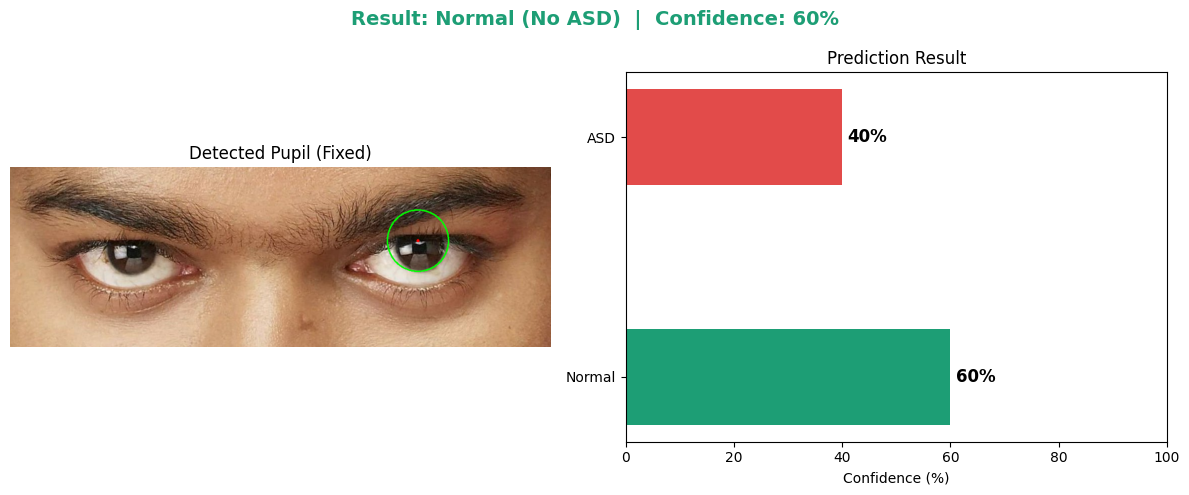

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_result)
axes[0].set_title('Detected Pupil (Fixed)')
axes[0].axis('off')

normal_score = 100 - score
bars = axes[1].barh(
    ['Normal', 'ASD'],
    [normal_score, score],
    color=['#1D9E75', '#E24B4A'],
    height=0.4
)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title('Prediction Result')
for bar, val in zip(bars, [normal_score, score]):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=12, fontweight='bold')

verdict = 'ASD Detected' if is_asd else 'Normal (No ASD)'
color   = '#E24B4A'       if is_asd else '#1D9E75'
fig.suptitle(f'Result: {verdict}  |  Confidence: {conf}%',
             fontsize=14, fontweight='bold', color=color)
plt.tight_layout()
plt.show()